In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


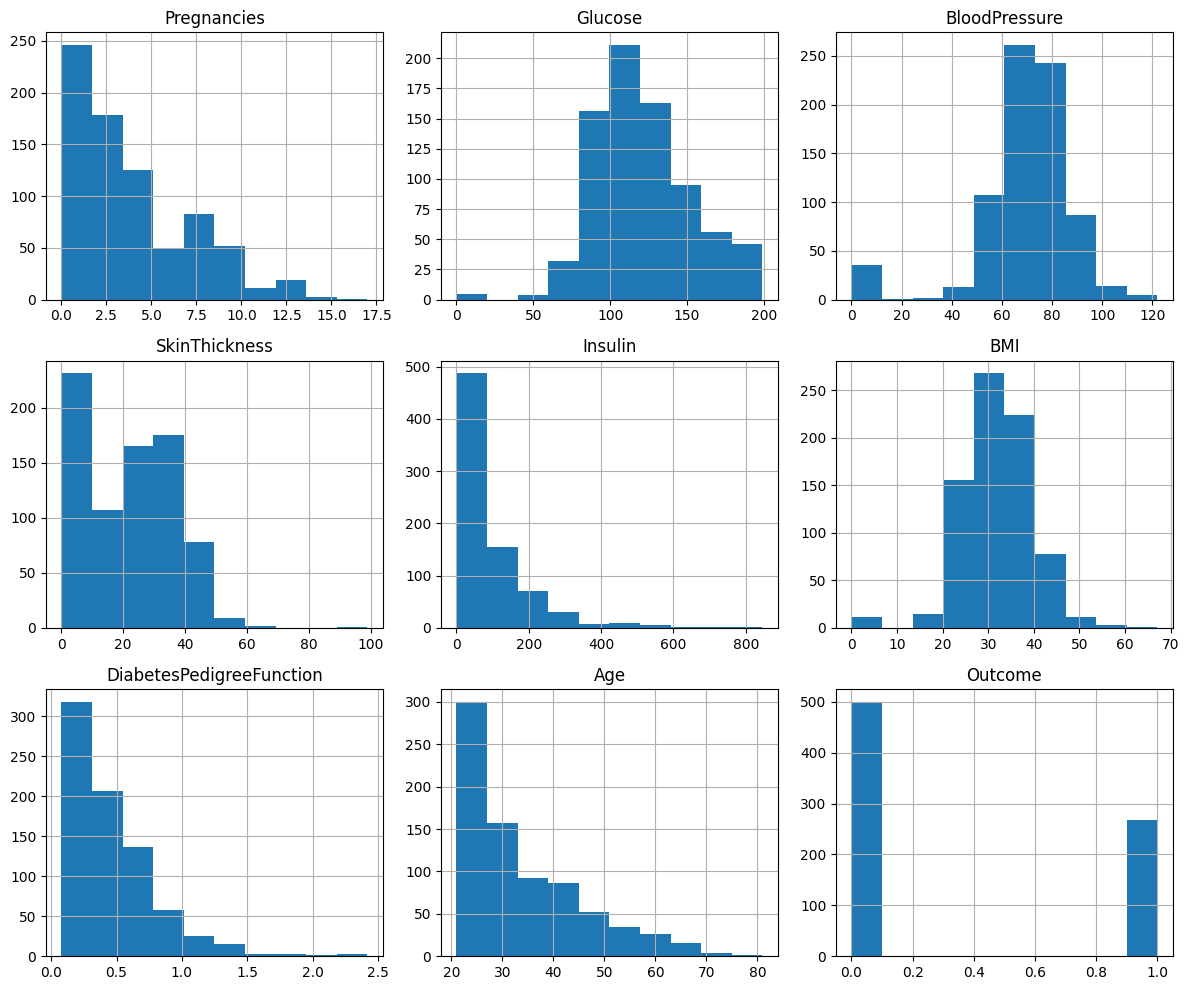

In [4]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


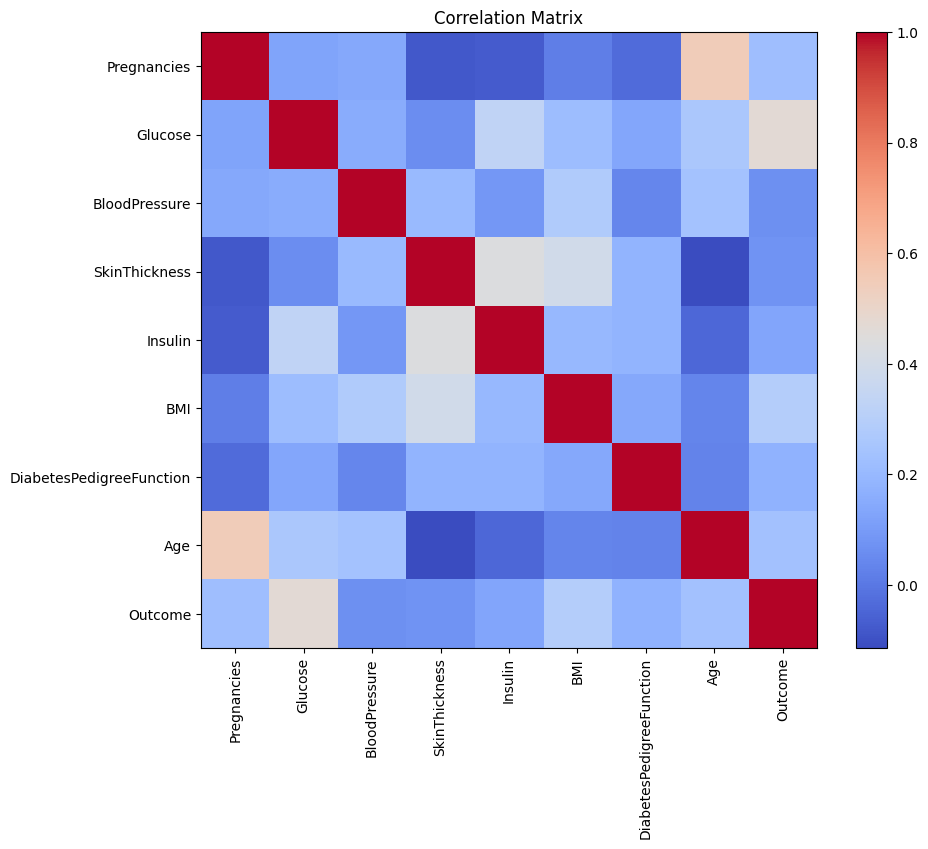

In [6]:
corr = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [7]:
# Statisitcal measures
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df['Outcome'].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

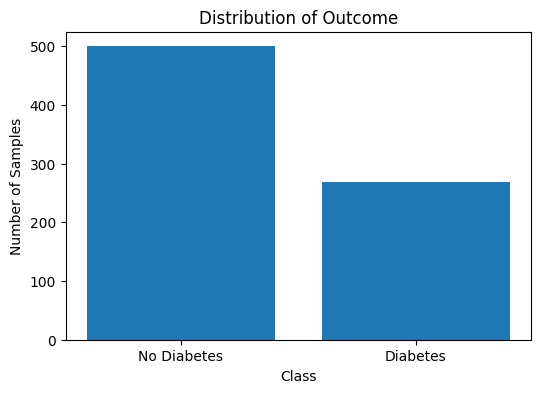

In [9]:


value_count = df['Outcome'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['No Diabetes', 'Diabetes'], value_count.sort_index())

plt.title('Distribution of Outcome')
plt.xlabel('Class')
plt.ylabel('Number of Samples')

plt.show()

In [10]:
# Spliting the data
X = df.drop('Outcome', axis=1)
y = df['Outcome']

## Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [12]:
X_train.shape

(614, 8)

In [13]:
X_test.shape

(154, 8)

In [14]:
X.shape

(768, 8)

In [15]:
# Works fine

## Data Preprocessing

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
X_train_scaled

array([[ 1.24763126,  2.34989414,  0.58197436, ..., -0.72716899,
         0.27484564,  2.94589207],
       [-0.54848971,  1.10082499, -0.86450579, ...,  0.87116898,
        -0.70196157, -0.69541861],
       [-0.84784321,  0.71649603,  0.78861438, ...,  1.34052219,
         1.92379672, -0.95551223],
       ...,
       [-0.84784321, -0.30838122,  1.30521443, ...,  0.12274089,
        -0.62344009,  1.03853886],
       [ 0.94827777, -1.20514882,  0.47865435, ..., -0.32124188,
         0.95327123,  0.258258  ],
       [-0.24913622, -0.18027157, -0.14126571, ...,  0.79505765,
        -0.9846389 , -0.43532499]], shape=(614, 8))

In [18]:
X_test_scaled

array([[-0.24913622,  0.23608481,  0.47865435, ..., -1.36143008,
        -0.61401751,  1.90551759],
       [ 0.05021728,  0.4282493 ,  0.16869432, ..., -1.01892909,
        -0.58574978,  2.33900695],
       [ 0.64892427, -0.56460054, -0.14126571, ..., -0.95550298,
        -0.67369384, -0.34862712],
       ...,
       [-0.84784321,  0.39622188,  1.71849447, ...,  0.12274089,
        -0.72080672,  1.03853886],
       [-0.84784321,  2.51003121,  0.37533434, ...,  1.4039483 ,
         2.92258994, -0.95551223],
       [-0.84784321,  0.55635896,  0.68529437, ...,  1.04876209,
        -0.71452501, -0.43532499]], shape=(154, 8))

In [19]:
# Works fine

## Training the Model

In [20]:
classifier = svm.SVC(kernel='linear')

In [21]:
classifier.fit(X_train_scaled, y_train)

SVC(kernel='linear')

## Model Evaluation

In [22]:
# Finding the accuracy score for training data
X_train_prediction = classifier.predict(X_train_scaled)
X_train_accuracy = accuracy_score(y_train, X_train_prediction)
print(f"Accuracy score for training data is: {X_train_accuracy}")

Accuracy score for training data is: 0.7833876221498371


In [23]:
# Finding the data accuracy score for testing data
X_test_prediction = classifier.predict(X_test_scaled)
X_test_accuracy = accuracy_score(y_test, X_test_prediction)
print(f"Accuracy score for testing data is: {X_test_accuracy}")

Accuracy score for testing data is: 0.7467532467532467


## Predictive System

In [25]:
new_data = pd.DataFrame({
    'Pregnancies': [6],
    'Glucose': [148],
    'BloodPressure': [72],
    'SkinThickness': [35],
    'Insulin': [0],
    'BMI': [33.6],
    'DiabetesPedigreeFunction': [0.627],
    'Age': [50]
})

scaled_data = scaler.transform(new_data)
prediction = classifier.predict(scaled_data)
if prediction[0] == 1:
    print("Prediction: Likely Diabetes (High Risk)")
else:
    print("Prediction: Likely No Diabetes (Low Risk)")

Prediction: Likely Diabetes (High Risk)
